# Naive Bayes

## Imports

### Import data

In [117]:
import pandas as pd
pd.set_option('display.max_columns', None)

df = pd.read_csv('../../data/model-ready.csv')
df.head()

,ISRC,Genre,Track,Album Name,Artist,All Time Rank,Track Score,Spotify Streams,Spotify Popularity,YouTube Views,YouTube Likes,TikTok Posts,TikTok Likes,TikTok Views,AirPlay Spins,Pandora Streams,Pandora Track Stations,Shazam Counts,Explicit Track,Length,Releases,Registration Country,Followers,TikTok Views per Post,TikTok Impact,TikTok View-to-Like Ratio,TikTok Likes per Post,YouTube View-to-Like Ratio,Shazam Conversion Rate,Days Since Release,Label Prob,Label
0,QM24S2402528,Other,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,1,725.4,390470936,92,84274754,1713126,5767700,651565900,5332281936,40975,18004655,22931,2669262,0,155.1510,1,United States,847504.0,924.507505,0.000011,8.183795,112.968044,49.193524,0.000493,344,0.734589,1
1,USUG12400910,Rap,Not Like Us,Not Like Us,Kendrick Lamar,2,545.9,323703884,92,116347040,3486739,674700,35223547,208339025,40778,7780028,28444,1118279,1,274.1920,5,United States,38589324.0,308.787646,0.000003,5.914765,52.206158,33.368430,0.003444,336,0.721077,1
2,QZJ842400387,Other,i like the way you kiss me,I like the way you kiss me,Artemas,3,538.4,601309283,92,122599116,2228730,3025400,275154237,3369120610,74333,5022621,5639,5285340,0,143.1865,8,United States,1133424.0,1113.611625,0.000009,12.244480,90.948022,55.008485,0.001514,382,0.771418,1
3,USSM12209777,Other,Flowers,Flowers - Single,Miley Cyrus,4,444.9,2031280633,85,1096100899,10629796,7189811,1078757968,14603725994,1474799,190260277,203384,11822942,0,200.4530,30,United States,25620499.0,2031.169664,0.000002,13.537537,150.039802,103.115883,0.000753,814,0.799485,1
4,USAT22311371,Other,Lovin On Me,Lovin On Me,Jack Harlow,6,410.1,670665438,83,131148091,1392593,4202367,214943489,2938686633,522042,138529362,50982,4517131,1,138.4110,13,United States,4106706.0,699.293192,0.000005,13.671903,51.148183,94.175396,0.001471,512,0.758437,1


### Import modules

For Naive Bayes, we use scikit-learn's MultinomialNB, GaussianNB, and CategoricalNB:
1. MultinomialNB: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html#sklearn.naive_bayes.MultinomialNB
2. GaussianNB: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html#sklearn.naive_bayes.GaussianNB
3. CategoricalNB: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.CategoricalNB.html#sklearn.naive_bayes.CategoricalNB

For plotting, we use scikit-learn's ConfusionMatrixDisplay:
1. ConfusionMatrixDisplay: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html

## Data Prep

### Custom functions to reduce code repetition

In [130]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = [4, 3]


def my_corr_plotter(df):
    custom_cmap = LinearSegmentedColormap.from_list(
        'black_seagreen_diverge', ['black', 'white', 'mediumseagreen']
    )
    sns.heatmap(df.corr(), annot=True, cmap=custom_cmap, fmt='.2f', vmin=-1, vmax=1, center=0, 
                annot_kws={'size': 8})
    plt.xticks(rotation=45)
    plt.xticks(fontsize=6)
    plt.yticks(fontsize=6)
    plt.show()

    
def my_binner(df):
    numeric_df = df.select_dtypes(include=[np.number])
    binned_df = pd.DataFrame(index=df.index)

    for col in numeric_df.columns:
        col_data = numeric_df[col].dropna()
        n = len(col_data)

        if n < 2:
            num_bins = 1
        else:
            # Sturge's Rule: k = 1 + log2(N)
            factor = 0.8
            num_bins = int(np.ceil(factor * (1 + np.log2(n))))
            num_bins = max(2, num_bins)

        unique_vals = col_data.nunique()
        actual_bins = min(num_bins, unique_vals)

        if actual_bins < 2:
            binned_series = pd.Series(0, index=col_data.index, dtype='Int64')
            binned_df[col] = binned_series.reindex(df.index)
        else:
            binned_series = pd.qcut(numeric_df[col], q=actual_bins, labels=False, duplicates='drop')
            binned_df[col] = binned_series.astype('Int64')

    return binned_df

def my_count_binner(df):
    numeric_df = df.select_dtypes(include=[np.number])
    binned_df = pd.DataFrame(index=df.index)

    for col in numeric_df.columns:
        col_data = numeric_df[col].dropna()
        n = len(col_data)
        
        if col_data.nunique() < 1:
            binned_series = pd.Series('medium', index=col_data.index, dtype='string')
            binned_df[col] = binned_series.reindex(df.index)
        else:
            try:
                binned_series = pd.qcut(col_data, q=5, labels=['low', 'low-medium', 'medium', 'medium-high', 'high'], duplicates='drop')
                binned_df[col] = binned_series.astype('string').reindex(df.index)
            except ValueError:
                binned_df[col] = pd.Series('medium', index=df.index, dtype='string')

    return binned_df

def my_count_vectorizer(df_binned, label_col='Label'):
    binned_only = df_binned.drop(columns=[label_col])

    collapsed_df = pd.DataFrame({
        'low': (binned_only == 'low').sum(axis=1).astype('Int64'),
        'low-medium': (binned_only == 'low-medium').sum(axis=1).astype('Int64'),
        'medium': (binned_only == 'medium').sum(axis=1).astype('Int64'),
        'medium-high': (binned_only == 'medium-high').sum(axis=1).astype('Int64'),
        'high': (binned_only == 'high').sum(axis=1).astype('Int64'),
        label_col: df_binned[label_col]
    })

    return collapsed_df

def my_bin_plotter(df):
    value_counts_dict = {}

    ordered_bins = ['low', 'low-medium', 'medium', 'medium-high', 'high']

    for col in df.columns:
        counts = df[col].value_counts()

        if df[col].dtype == 'string':
            counts = counts.reindex(ordered_bins, fill_value=0)

        elif pd.api.types.is_integer_dtype(df[col]) or pd.api.types.is_float_dtype(df[col]):
            counts = counts.sort_index()

        value_counts_dict[col] = counts

    num_cols_to_plot = len(df.columns)
    ncols_grid = 3
    nrows_grid = int(np.ceil(num_cols_to_plot / ncols_grid))
    fig, axes = plt.subplots(nrows=nrows_grid, ncols=ncols_grid, figsize=(14, 4 * nrows_grid))
    axes = axes.flatten()

    for i, (col_name, counts) in enumerate(value_counts_dict.items()):
        ax = axes[i]
        x = counts.index.tolist()
        y = counts.values.tolist()
        ax.bar(x, y, color='mediumseagreen')
        ax.set_title(col_name)
        ax.set_xlabel('Binned Value')
        ax.set_ylabel('Count')
        ax.set_xticks(range(len(x)))
        ax.set_xticklabels(x, ha='center')
        ax.tick_params(axis='x', labelsize=9)

    if len(value_counts_dict) < len(axes):
        for j in range(len(value_counts_dict), len(axes)):
            fig.delaxes(axes[j])

    fig.tight_layout()
    plt.show()

### Feature selection

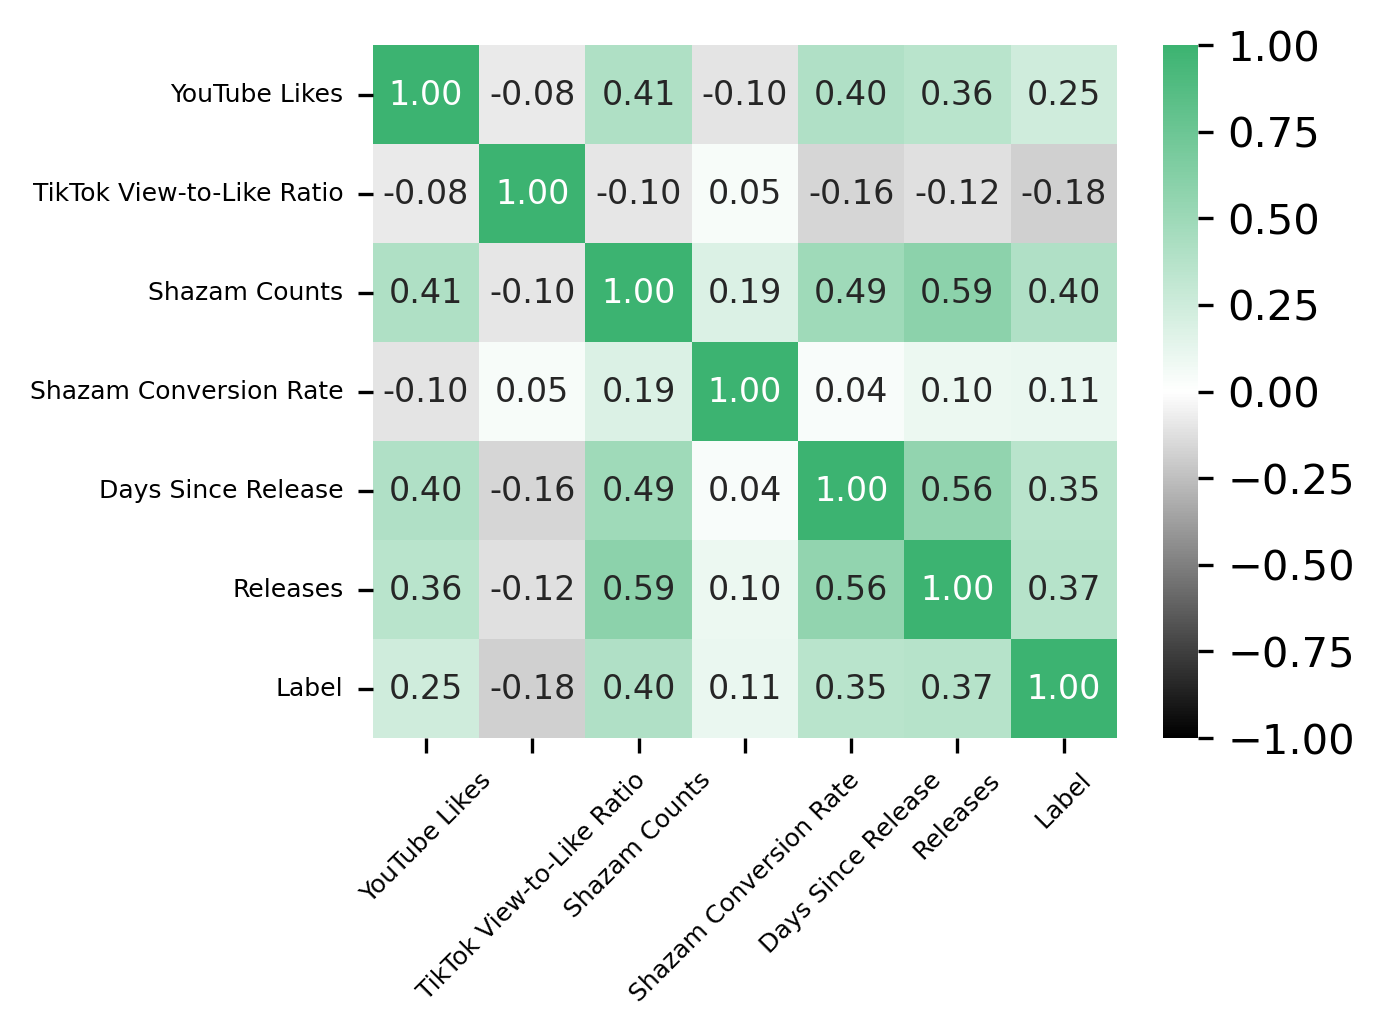

In [139]:
df_nb = df[['YouTube Likes',
             'TikTok View-to-Like Ratio', # TikTok Views / (TikTok Likes + 1)
             'Shazam Counts',
             'Shazam Conversion Rate', # Shazam Counts / (YouTube Views + TikTok Views + 1)
             'Days Since Release',
             'Releases',
             'Label']]
df_nb.head()

my_corr_plotter(df_nb)

### Multinomial Naive Bayes

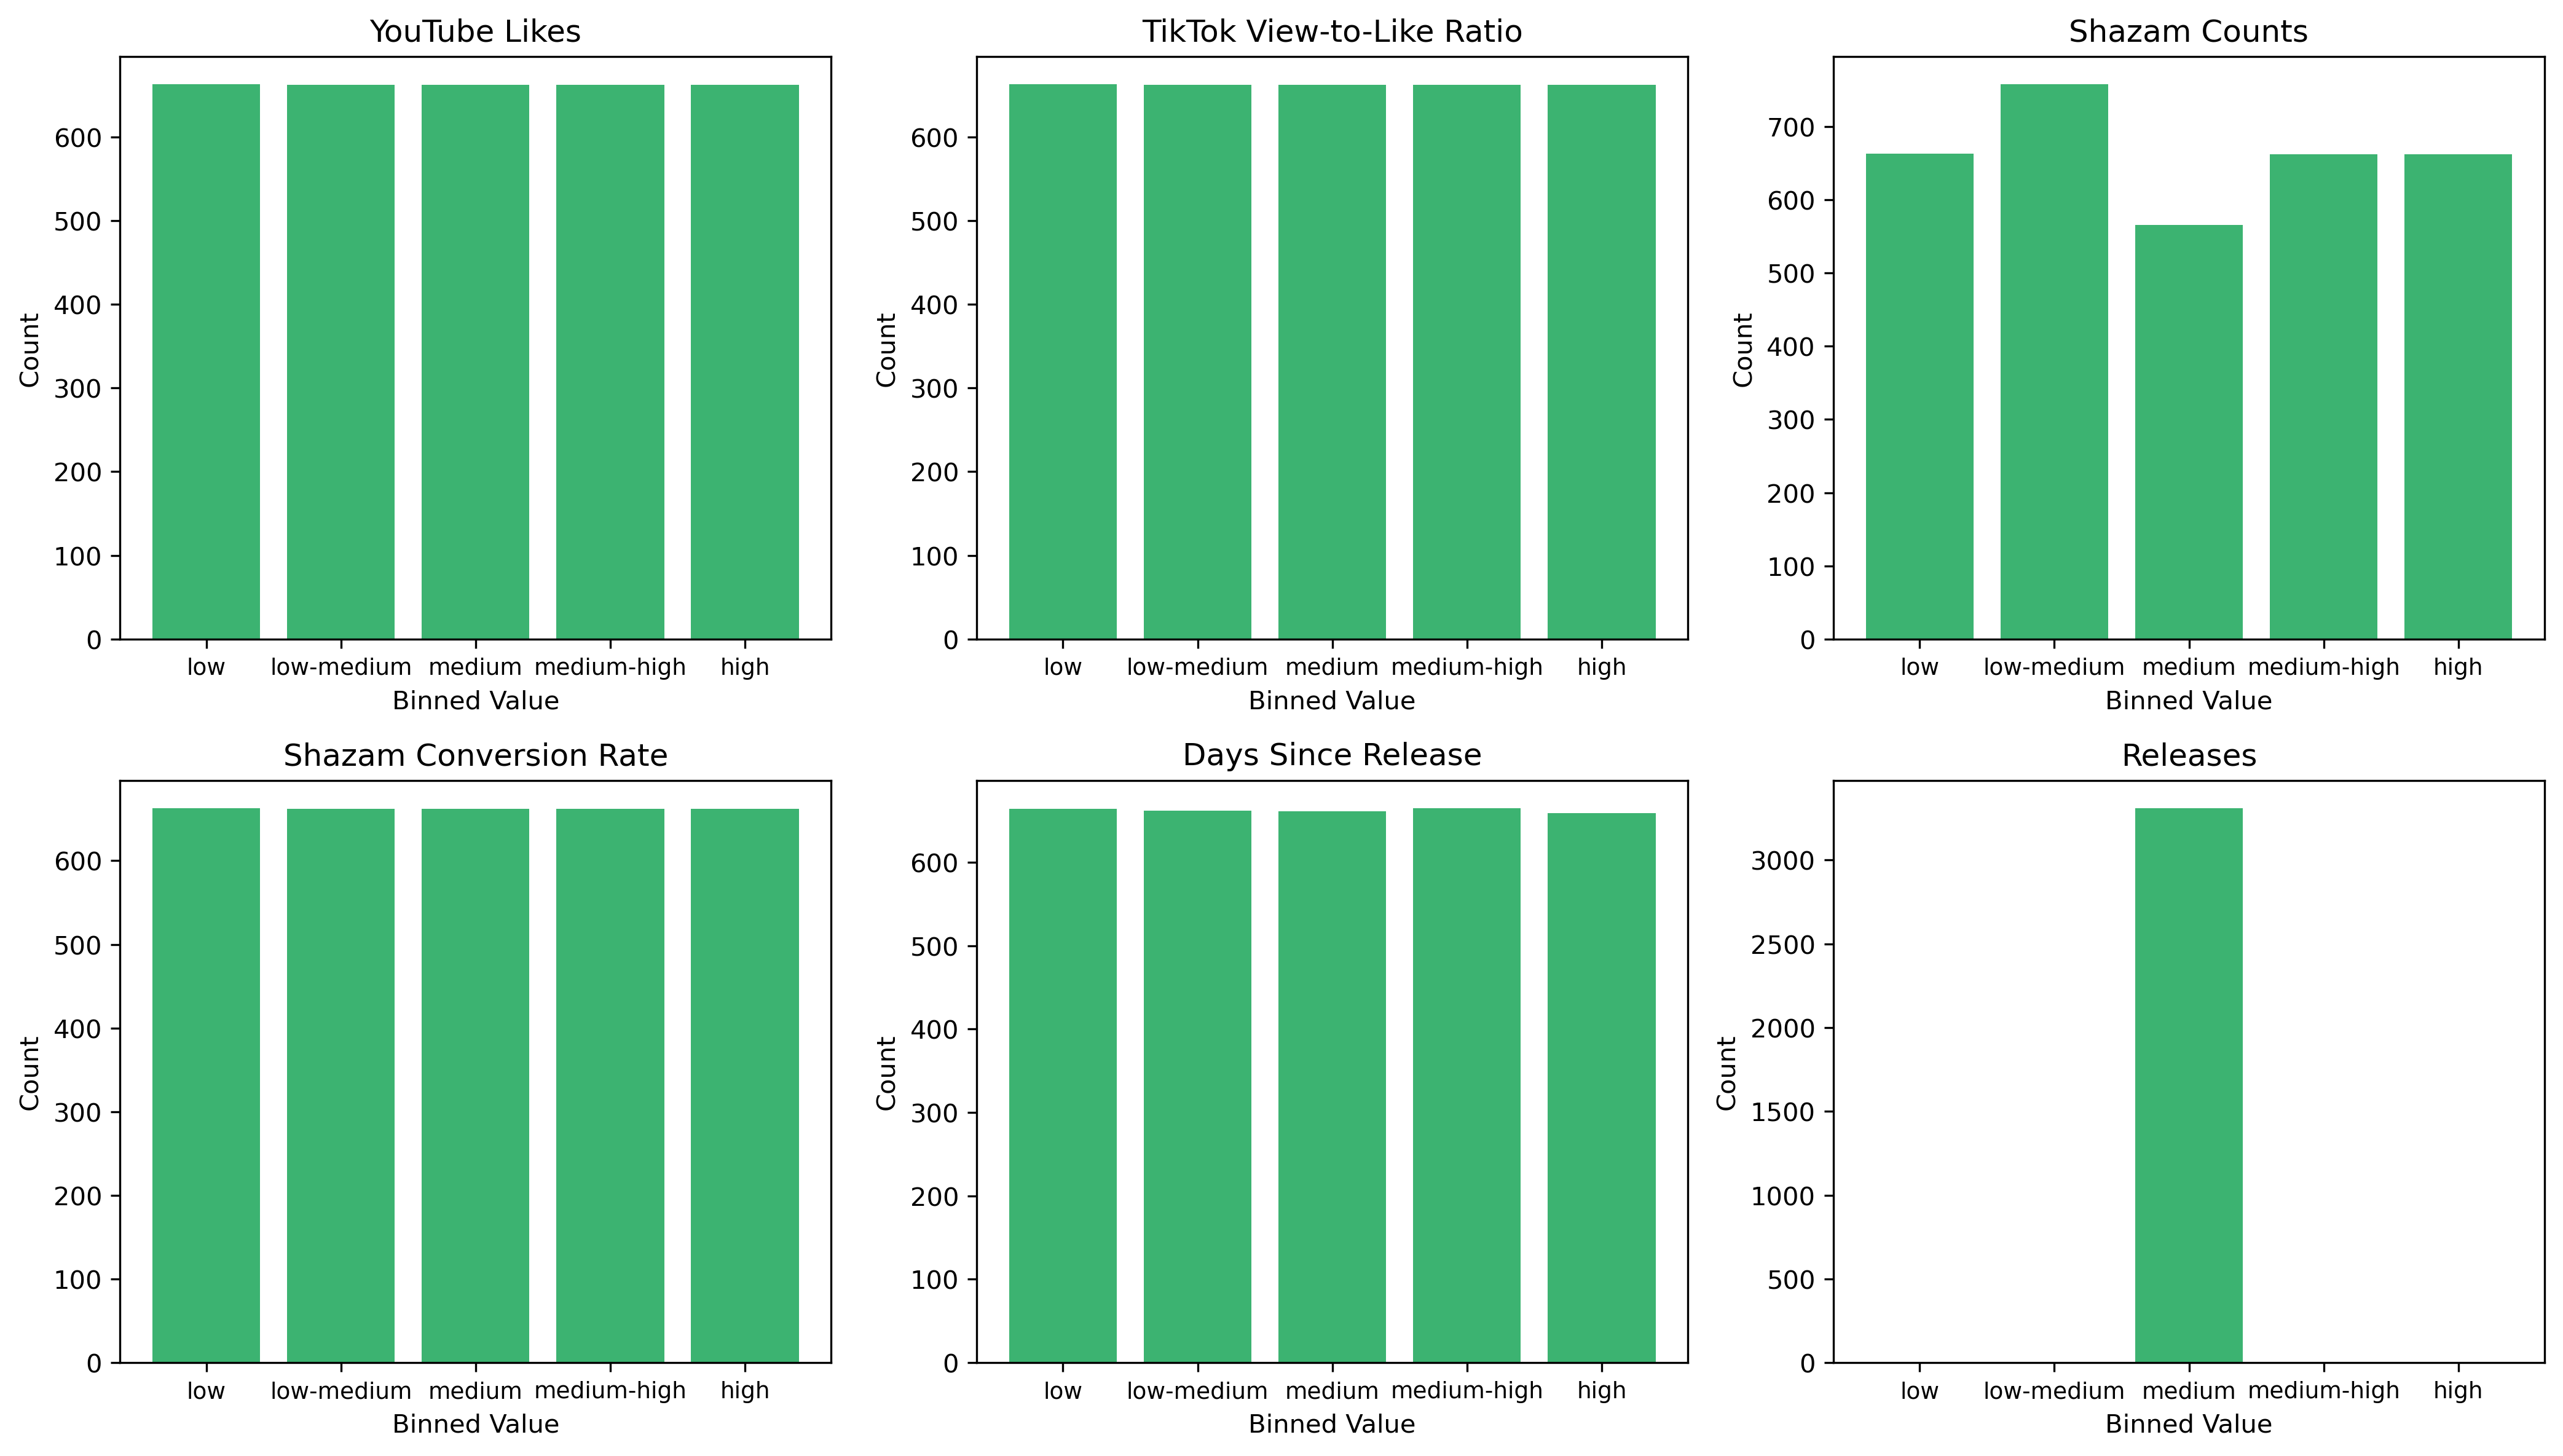

,low,low-medium,medium,medium-high,high,Label
0,2,1,2,1,0,1
1,2,0,2,2,0,1
2,1,0,3,1,1,1
3,0,2,1,1,2,1
4,1,0,3,0,2,1


In [140]:
# 1. Define Multinomial Naive Bayes dataset
df_mnb = df_nb.copy()

df_mnb_binned = my_count_binner(df_mnb.drop('Label', axis=1))
df_mnb_binned['Label'] = df_mnb['Label']

my_bin_plotter(df_mnb_binned.drop('Label', axis=1))

df_mnb_collapsed = my_count_vectorizer(df_mnb_binned)
df_mnb_collapsed.head()

### Gaussian Naive Bayes

In [141]:
# 1. Define Gaussian Naive Bayes dataset
df_gnb = df_nb.copy()

### Categorical Naive Bayes

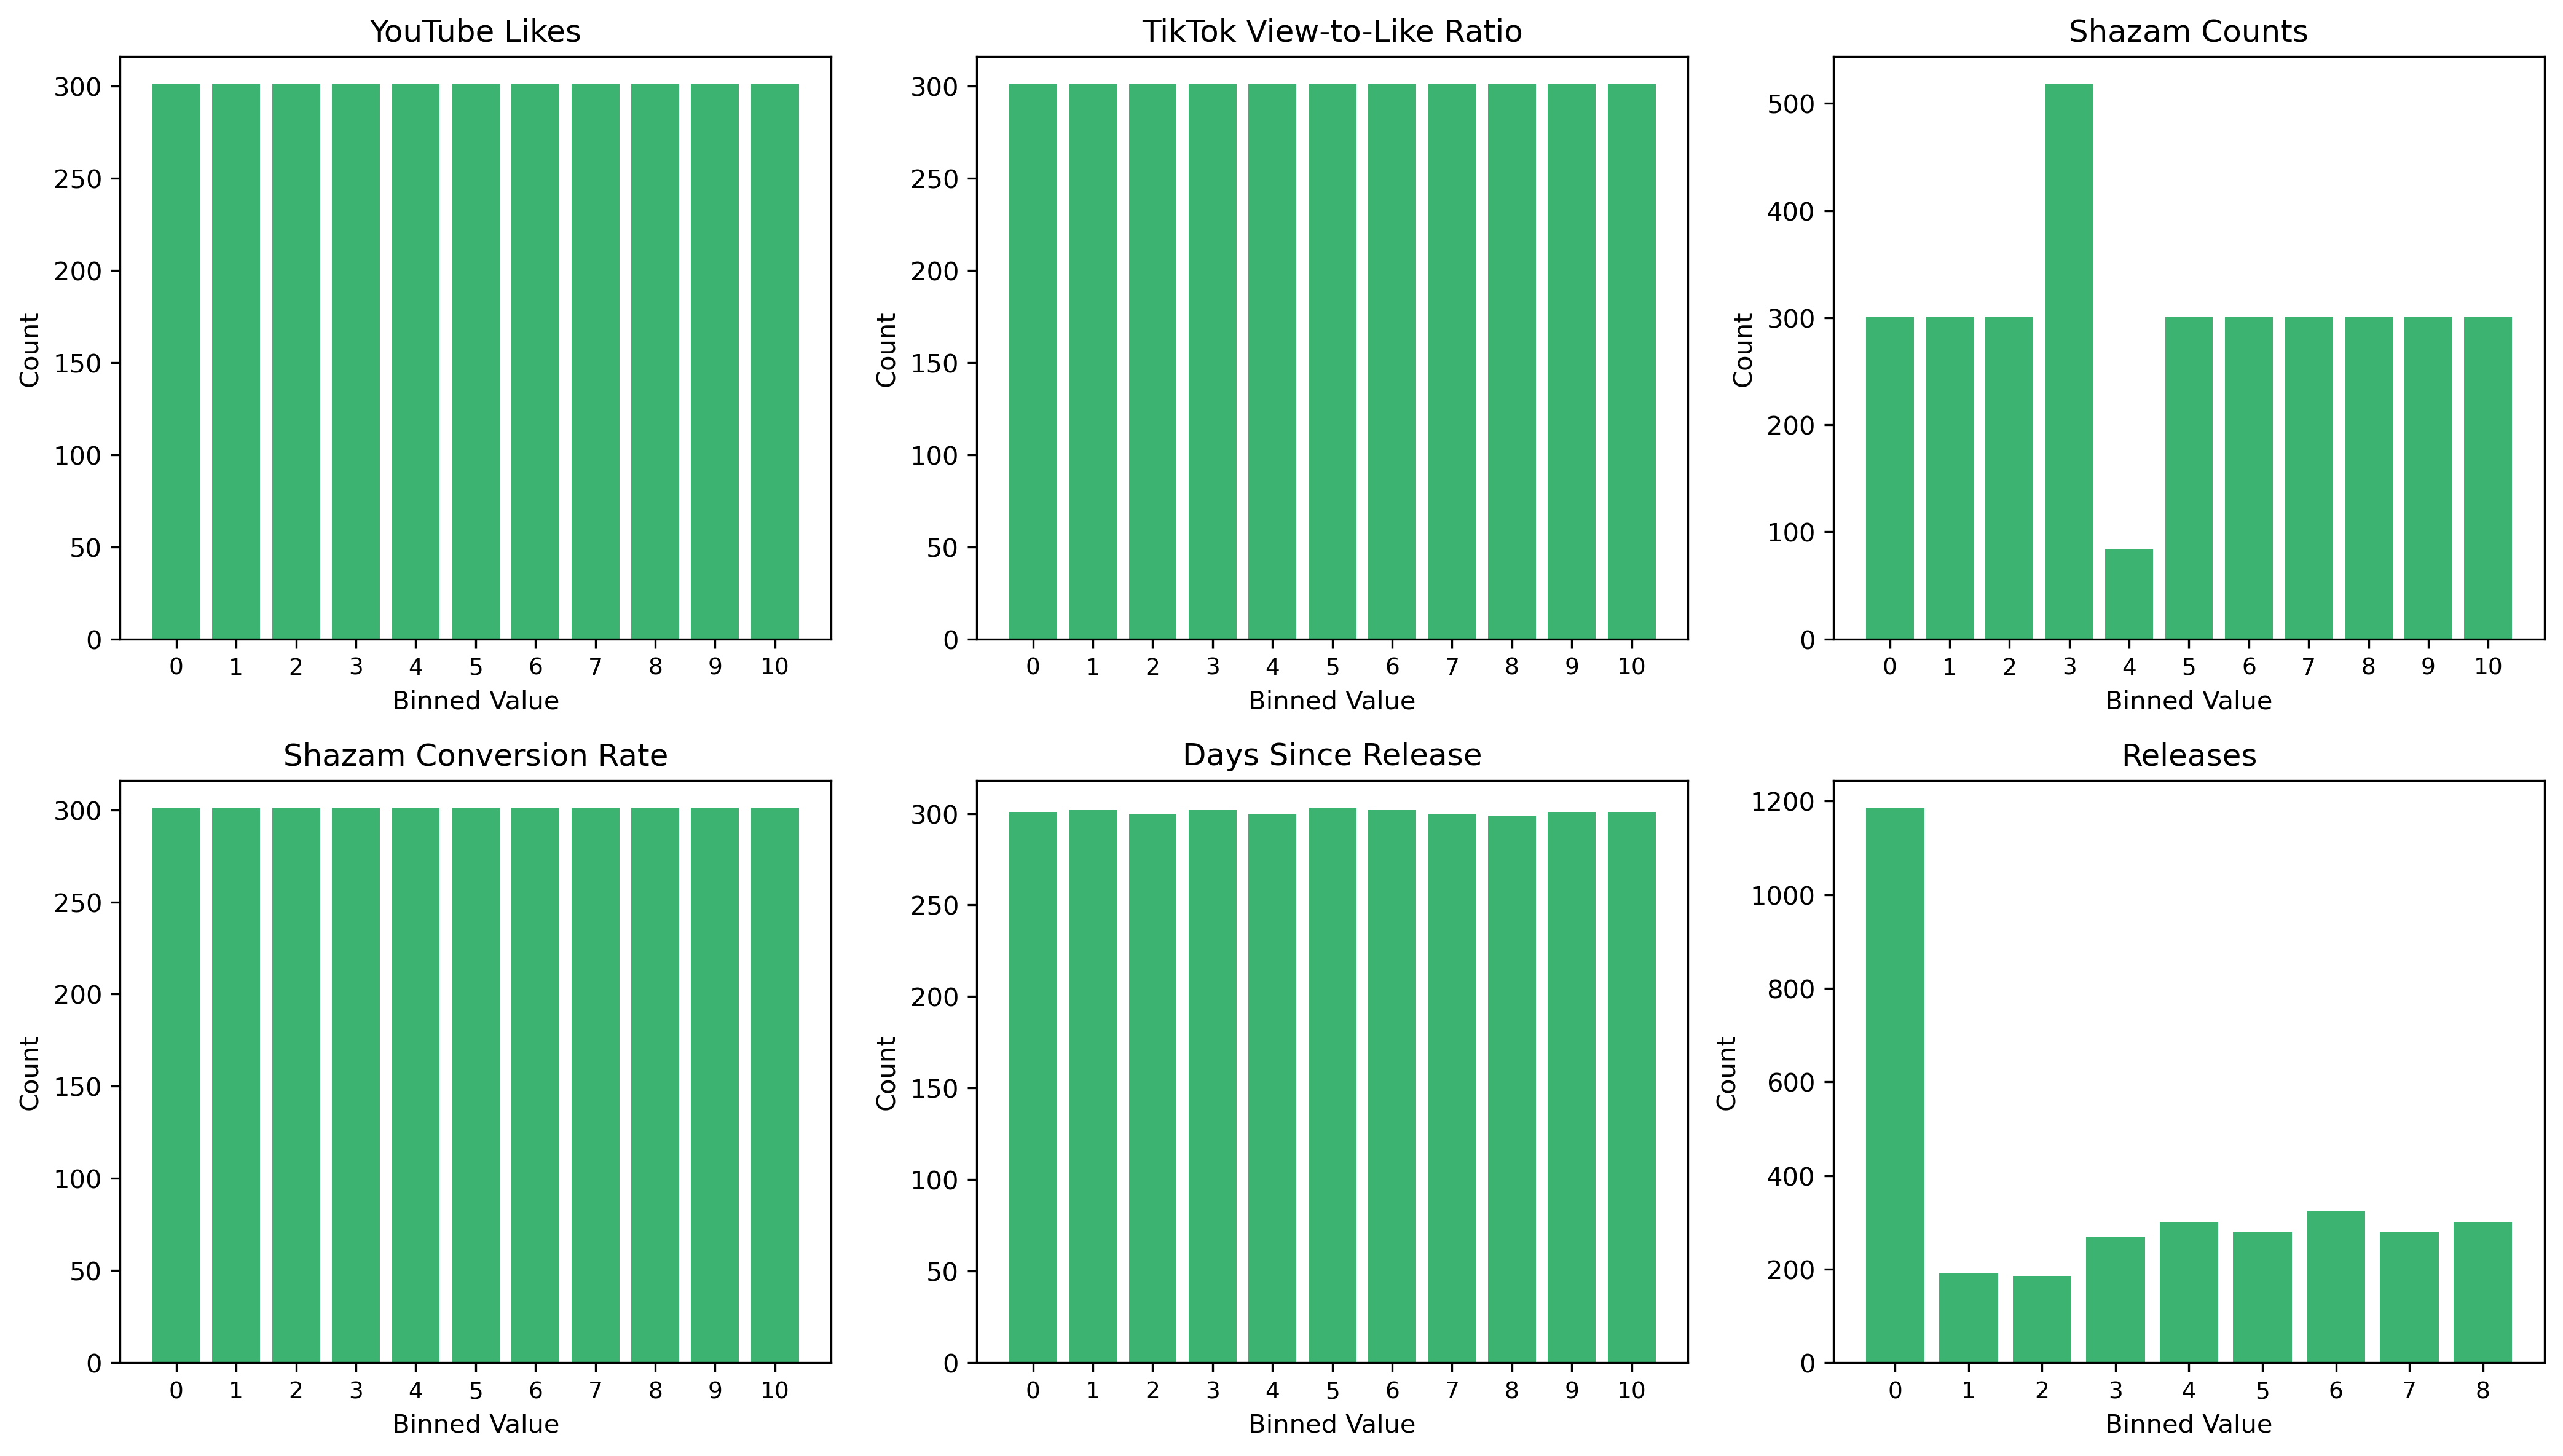

In [142]:
# 1. Define Categorical Naive Bayes dataset
df_cnb = df_nb.copy()

df_cnb_binned = my_binner(df_cnb.drop('Label', axis=1))
df_cnb_binned['Label'] = df_cnb['Label']
    
my_bin_plotter(df_cnb_binned.drop('Label', axis=1))

## Model Data

### Custom classes to reduce code repetition

In [143]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)

RSEED = 22
SKEW_THRESHOLD = 0.5


class MyScaler:
    def __init__(self):
        self.scaler_std = StandardScaler()
        self.scaler_minmax = MinMaxScaler()
        
    def log(self, train_X, test_X):
        transformed_cols = []
        for col in train_X.columns:
            if pd.api.types.is_numeric_dtype(train_X[col]):
                skewness = train_X[col].skew()
                if skewness > SKEW_THRESHOLD:
                    transformed_cols.append(col)
        
        for col in transformed_cols:
            train_X[col] = np.log1p(train_X[col])
            test_X[col] = np.log1p(test_X[col])
            
        print(f'Log transformed (skewness > {SKEW_THRESHOLD}):\n{transformed_cols}\n')
            
        return train_X, test_X
        
    def standard(self, train_X, test_X):
        train_X = pd.DataFrame(self.scaler_std.fit_transform(train_X), columns=train_X.columns)
        test_X = pd.DataFrame(self.scaler_std.transform(test_X), columns=test_X.columns)
        return train_X, test_X
    
    def minmax(self, train_X, test_X):
        train_X = pd.DataFrame(self.scaler_minmax.fit_transform(train_X), columns=train_X.columns)
        test_X = pd.DataFrame(self.scaler_minmax.transform(test_X), columns=test_X.columns)
        return train_X, test_X
    
    
class MyResults:
    def __init__(self, y_true, y_pred, classes):
        self.y_true = y_true
        self.y_pred = y_pred
        self.classes = classes
        self.results_df = pd.DataFrame({
            'Actual': y_true.values,
            'Predicted': y_pred
        }, index=y_true.index)
        self.results_df['Correct'] = self.results_df['Actual'] == self.results_df['Predicted']
        
    def print_metrics(self):
        accuracy = accuracy_score(self.y_true, self.y_pred)
        precision = precision_score(self.y_true, self.y_pred)
        recall = recall_score(self.y_true, self.y_pred)
        f1 = f1_score(self.y_true, self.y_pred)

        print(f'\nAccuracy: {accuracy:.4f}')
        print(f'Precision: {precision:.4f}')
        print(f'Recall:    {recall:.4f}')
        print(f'F1 Score:  {f1:.4f}')

    def plot_confusion_matrix(self):
        cm = confusion_matrix(self.y_true, self.y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=self.classes)
        custom_cmap = LinearSegmentedColormap.from_list(
            'black_to_seagreen', ['black', 'seagreen', 'mediumseagreen', 'mediumspringgreen']
        )
        disp.plot(cmap=custom_cmap)
        plt.title('Confusion Matrix')
        plt.show()

    def plot_barcode(self, color_correct='mediumseagreen', color_incorrect='black'):
        correctness_map = self.results_df['Correct'].astype(int).values.reshape(1, -1)
        cmap = ListedColormap([color_incorrect, color_correct])
        num_samples = len(self.results_df)
        fig_width = num_samples * 0.01
        fig_height = 0.5

        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
        ax.imshow(correctness_map, cmap=cmap, interpolation='nearest', aspect='auto')
        ax.axis('off')
        fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
        plt.show()

### Multinomial Naive Bayes

Training Data: (2648 rows ~80.0%)



,low,low-medium,medium,medium-high,high,Label
507,1,2,2,1,0,1
1338,0,2,3,1,0,1
2965,1,0,4,1,0,1
1479,0,3,1,1,1,1
839,1,0,3,2,0,1


Testing Data: (663 rows ~20.0%)



,low,low-medium,medium,medium-high,high,Label
1317,0,1,5,0,0,0
441,1,1,3,0,1,1
568,0,2,2,1,1,1
1639,0,0,4,1,1,1
357,0,1,2,3,0,1


Feature Names:
['low' 'low-medium' 'medium' 'medium-high' 'high']

Class Names:
['Low', 'High']


Accuracy: 0.7481
Precision: 0.7947
Recall:    0.8005
F1 Score:  0.7976


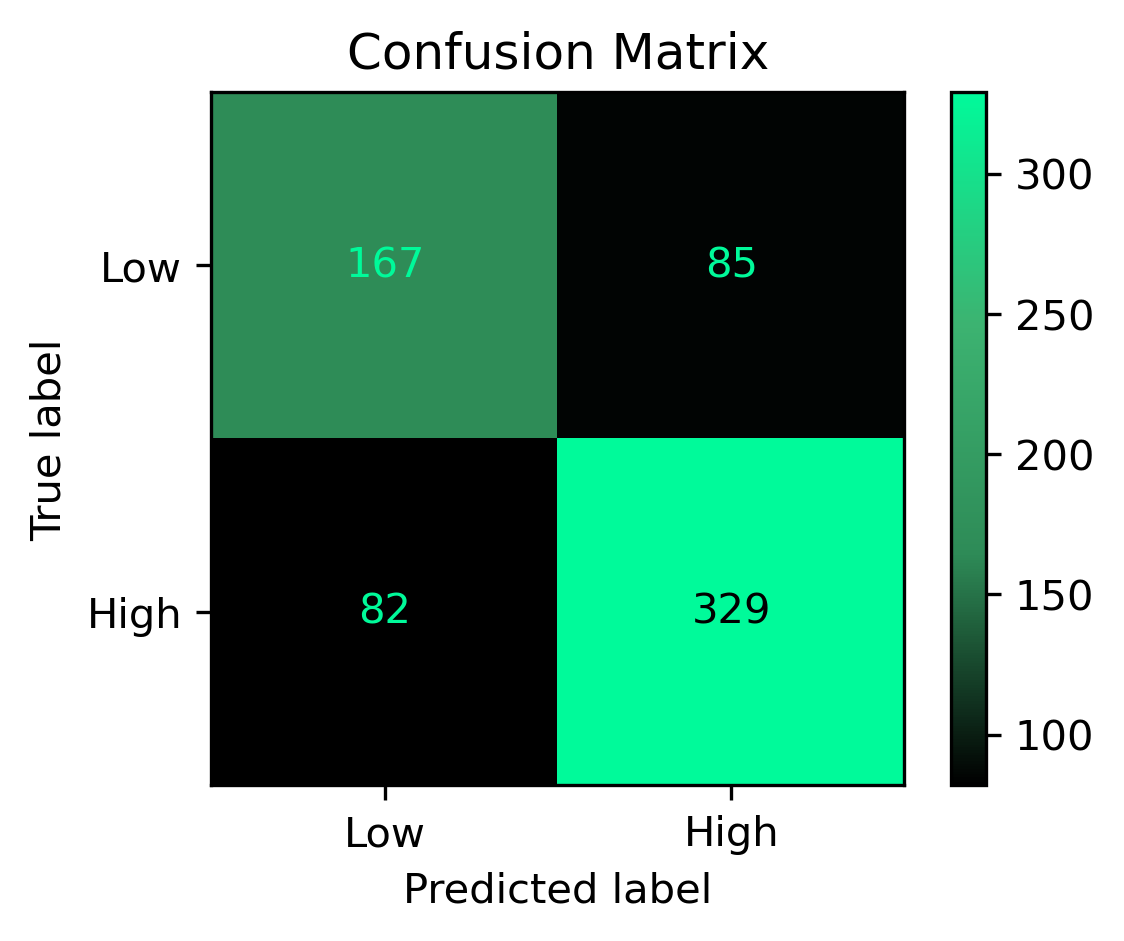

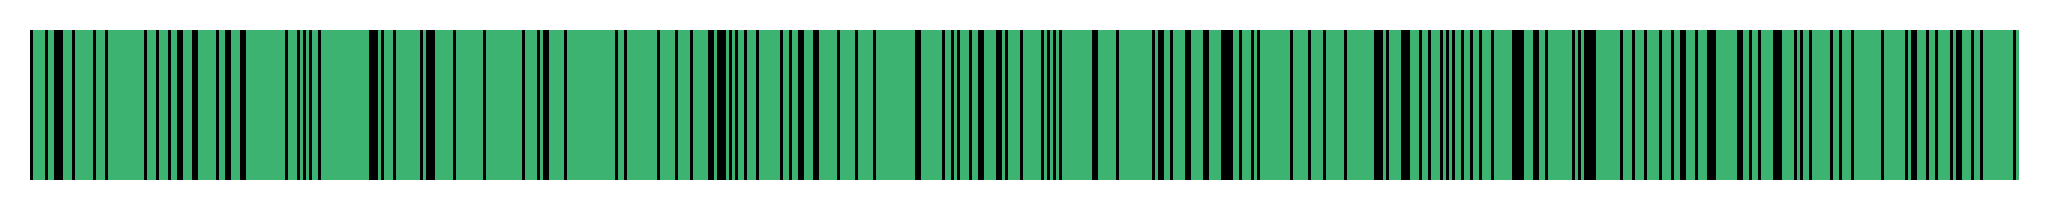

In [144]:
from sklearn.naive_bayes import MultinomialNB

TEST_SIZE = 0.2


# 2. Train-test split
train_df, test_df = train_test_split(df_mnb_collapsed, test_size=TEST_SIZE, random_state=RSEED)

df_len, train_len, test_len = (len(x) for x in [df, train_df, test_df])

print(f'Training Data: ({train_len} rows ~{round(train_len/df_len, 2)*100}%)\n')
display(train_df.head())
print(f'Testing Data: ({test_len} rows ~{round(test_len/df_len, 2)*100}%)\n')
display(test_df.head())


# 3. X-y split
train_y = train_df['Label']
train_X = train_df.drop(['Label'], axis=1)

test_y = test_df['Label']
test_X = test_df.drop(['Label'], axis=1)

features = train_X.columns.values
classes = ['Low', 'High']
print(f'Feature Names:\n{features}\n')
print(f'Class Names:\n{classes}\n')


# 4. Normalization
# -- Counts do not need normalization


# 5. Training
NB = MultinomialNB()
NB.fit(train_X, train_y)


# 6. Prediction
prediction = NB.predict(test_X)


# 7. Results
results = MyResults(test_y, prediction, classes)

# -- Via metrics
results.print_metrics()
# -- Via confusion matrix
results.plot_confusion_matrix()
# -- Via prediction barcode
results.plot_barcode()

### Gaussian Naive Bayes

Training Data: (2648 rows ~80.0%)



,YouTube Likes,TikTok View-to-Like Ratio,Shazam Counts,Shazam Conversion Rate,Days Since Release,Releases,Label
507,1117686,10.671368,554474,0.003282,558,2,1
1338,2439195,13.360463,701730,0.000800,1472,5,1
2965,2333652,7.224198,961364,0.003093,1674,1,1
1479,6533684,8.396780,855525,0.000983,2486,39,1
839,1156874,10.873670,1347624,0.003357,632,22,1


Testing Data: (663 rows ~20.0%)



,YouTube Likes,TikTok View-to-Like Ratio,Shazam Counts,Shazam Conversion Rate,Days Since Release,Releases,Label
1317,1213273,9.856405,977339,0.002192,1065,2,0
441,862952,14.516485,1434689,0.001962,694,1,1
568,11144552,9.936439,855525,0.000637,2157,41,1
1639,1790062,9.494025,4522347,0.006620,1598,26,1
357,3626173,8.558971,2592470,0.002937,2249,2,1


Feature Names:
['YouTube Likes' 'TikTok View-to-Like Ratio' 'Shazam Counts'
 'Shazam Conversion Rate' 'Days Since Release' 'Releases']

Class Names:
['Low', 'High']

Log transformed (skewness > 0.5):
['YouTube Likes', 'TikTok View-to-Like Ratio', 'Shazam Counts', 'Shazam Conversion Rate', 'Days Since Release', 'Releases']


Accuracy: 0.7934
Precision: 0.8827
Recall:    0.7689
F1 Score:  0.8218


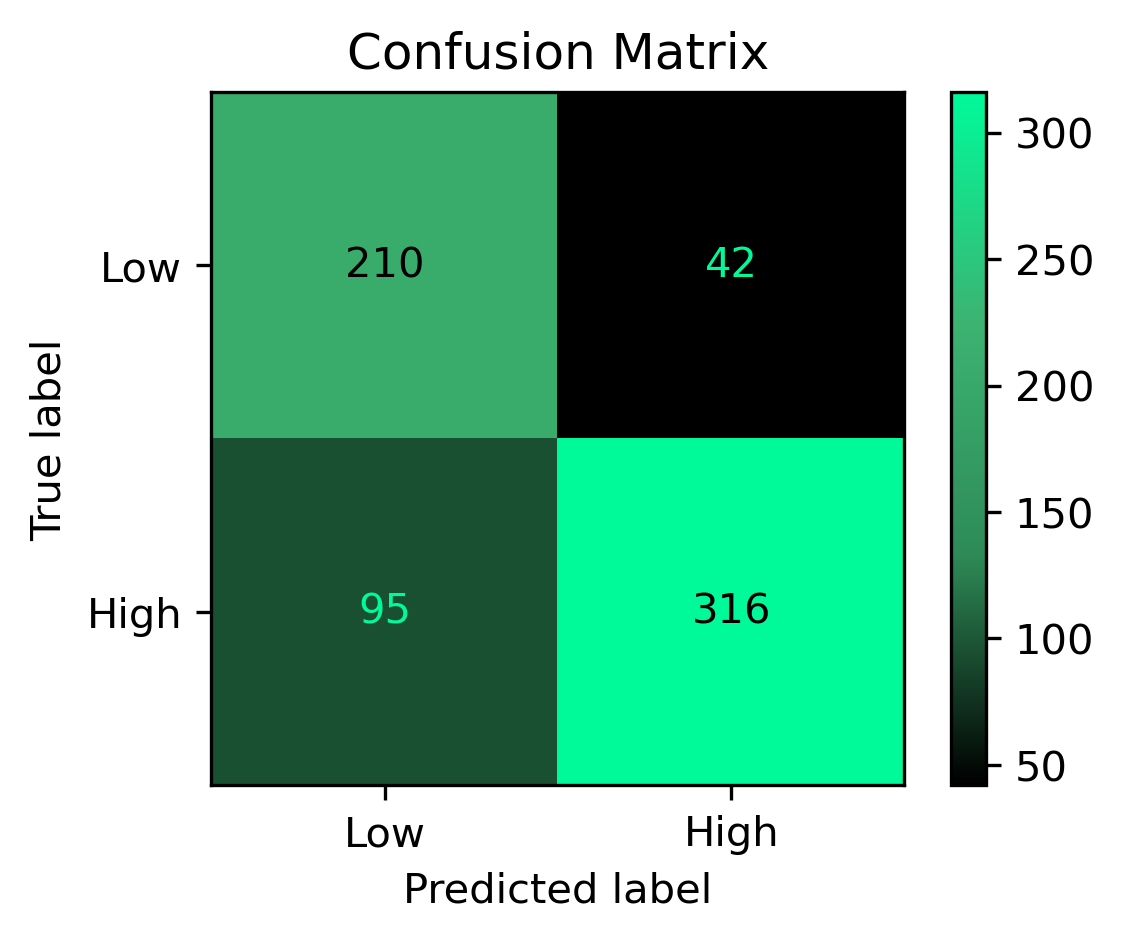

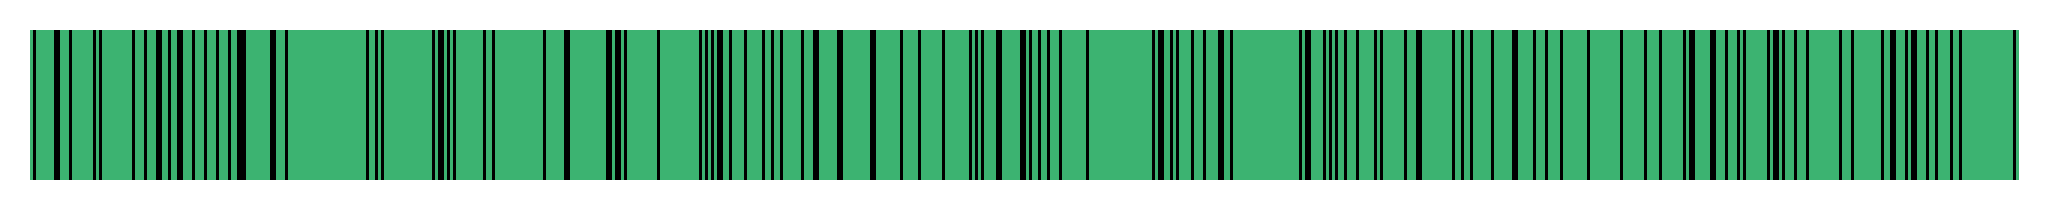

In [145]:
from sklearn.naive_bayes import GaussianNB

TEST_SIZE = 0.2


# 2. Train-test split
train_df, test_df = train_test_split(df_gnb, test_size=TEST_SIZE, random_state=RSEED)

df_len, train_len, test_len = (len(x) for x in [df, train_df, test_df])

print(f'Training Data: ({train_len} rows ~{round(train_len/df_len, 2)*100}%)\n')
display(train_df.head())
print(f'Testing Data: ({test_len} rows ~{round(test_len/df_len, 2)*100}%)\n')
display(test_df.head())


# 3. X-y split
train_y = train_df['Label']
train_X = train_df.drop(['Label'], axis=1)

test_y = test_df['Label']
test_X = test_df.drop(['Label'], axis=1)

features = train_X.columns.values
classes = ['Low', 'High']
print(f'Feature Names:\n{features}\n')
print(f'Class Names:\n{classes}\n')


# 4. Normalization
scaler = MyScaler()

# -- Log transform
train_X, test_X = scaler.log(train_X, test_X)
# -- StandardScaler
train_X, test_X = scaler.standard(train_X, test_X)


# 5. Training
NB = GaussianNB()
NB.fit(train_X, train_y)


# 6. Prediction
prediction = NB.predict(test_X)


# 7. Results
results = MyResults(test_y, prediction, classes)

# -- Via metrics
results.print_metrics()
# -- Via confusion matrix
results.plot_confusion_matrix()
# -- Via prediction barcode
results.plot_barcode()

### Categorical Naive Bayes

Training Data: (2648 rows ~80.0%)



,YouTube Likes,TikTok View-to-Like Ratio,Shazam Counts,Shazam Conversion Rate,Days Since Release,Releases,Label
507,4,6,2,6,0,0,1
1338,6,8,3,2,5,3,1
2965,6,1,4,6,6,0,1
1479,9,3,3,3,8,7,1
839,4,6,5,6,1,6,1


Testing Data: (663 rows ~20.0%)



,YouTube Likes,TikTok View-to-Like Ratio,Shazam Counts,Shazam Conversion Rate,Days Since Release,Releases,Label
1317,4,5,5,5,4,0,0
441,3,9,6,5,1,0,1
568,10,5,3,2,7,7,1
1639,5,5,8,8,6,6,1
357,7,4,7,6,7,0,1


Feature Names:
['YouTube Likes' 'TikTok View-to-Like Ratio' 'Shazam Counts'
 'Shazam Conversion Rate' 'Days Since Release' 'Releases']

Class Names:
['Low', 'High']


Accuracy: 0.8084
Precision: 0.8817
Recall:    0.7981
F1 Score:  0.8378


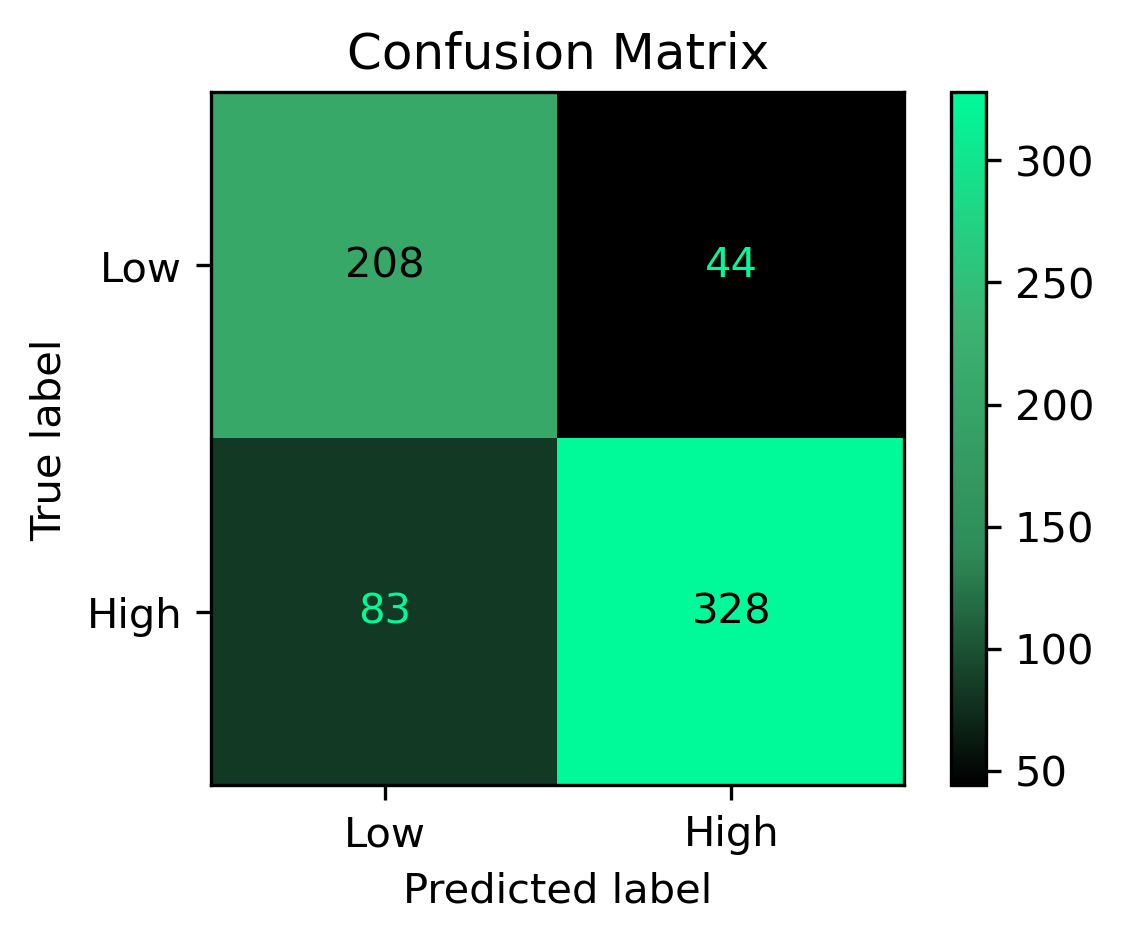

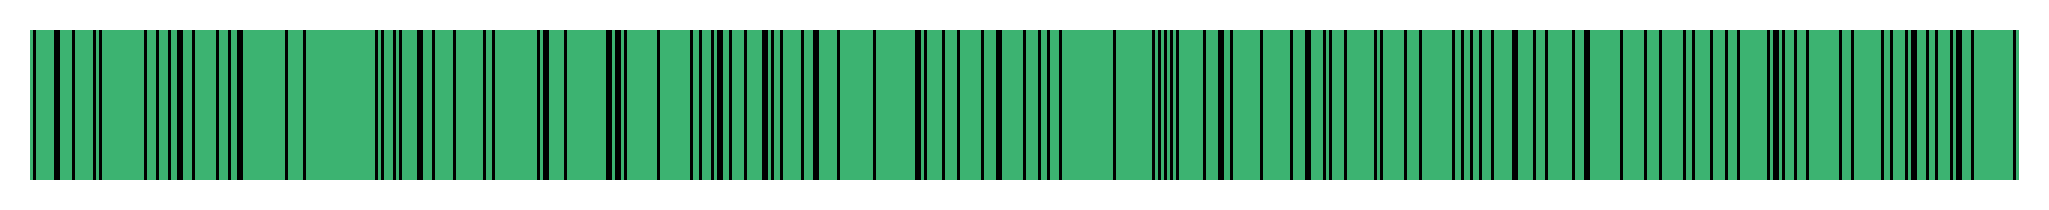

In [146]:
from sklearn.naive_bayes import CategoricalNB

TEST_SIZE = 0.2


# 2. Train-test split
train_df, test_df = train_test_split(df_cnb_binned, test_size=TEST_SIZE, random_state=RSEED)

df_len, train_len, test_len = (len(x) for x in [df, train_df, test_df])

print(f'Training Data: ({train_len} rows ~{round(train_len/df_len, 2)*100}%)\n')
display(train_df.head())
print(f'Testing Data: ({test_len} rows ~{round(test_len/df_len, 2)*100}%)\n')
display(test_df.head())


# 3. X-y split
train_y = train_df['Label']
train_X = train_df.drop(['Label'], axis=1)

test_y = test_df['Label']
test_X = test_df.drop(['Label'], axis=1)

features = train_X.columns.values
classes = ['Low', 'High']
print(f'Feature Names:\n{features}\n')
print(f'Class Names:\n{classes}\n')


# 4. Normalization
# -- Categories are not normalizable


# 5. Training
NB = CategoricalNB()
NB.fit(train_X, train_y)


# 6. Prediction
prediction = NB.predict(test_X)


# 7. Results
results = MyResults(test_y, prediction, classes)

# -- Via metrics
results.print_metrics()
# -- Via confusion matrix
results.plot_confusion_matrix()
# -- Via prediction barcode
results.plot_barcode()